# Notebook 07 Data Wrangling & EDA: Sleep & Insomnia
**Proyek Analisis Data: HAPI (Human Activity Pattern Intelligence)**

### Profil Proyek & Tim
- **Tema Capstone:** Healthy Lives & Well-being
- **Target User:** Mahasiswa (fokus pada aspek akademik & lingkungan belajar)
- **Tujuan Proyek:** Pengembangan *platform* Webapp untuk *mood management & tracker* serta diagnosis mandiri tingkat kelelahan (*fatigue*).
- **Tim DS:** Greycia Febrina Michelle (CDCC700D6X2644) & Khazel Hayfa Yosmi (CDCC308D6X0629)

### Sumber Dataset
Dataset yang digunakan dalam notebook ini adalah **Sleep and Insomnia Dataset** yang diperoleh dari Mendeley Data. Dataset ini berisi berbagai indikator terkait kualitas tidur, gangguan tidur, serta dampaknya terhadap aktivitas sehari-hari. Data dikumpulkan melalui kuesioner sehingga mayoritas variabel berbentuk skala ordinal berbasis persepsi responden.

### Tujuan Notebook
Melakukan Data Wrangling (*Gathering, Assessing, Cleaning*) dan Exploratory Data Analysis (EDA) untuk memahami pola tidur dan gejala insomnia yang dialami mahasiswa. Analisis ini bertujuan mengidentifikasi hubungan antara durasi tidur, kualitas tidur, kelelahan di siang hari, serta dampaknya terhadap aktivitas akademik. Insight yang diperoleh akan digunakan untuk mendukung pengembangan fitur pemantauan kesehatan dan deteksi dini risiko *fatigue* pada aplikasi HAPI.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

PALETTE = ['#00bcff','#00adfd','#009efa','#008ff6','#007ff1',
           '#006eea','#005ce1','#004ad6','#0034c8']
C_MAIN = '#007ff1'
C_DARK = '#0034c8'
C_LIGHT = '#00bcff'
C_GREY = '#e0e0e0'
HAPI_CMAP = LinearSegmentedColormap.from_list('hapi', [C_LIGHT, C_DARK], N=256)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / 'data').exists():
        break
    ROOT = ROOT.parent

RAW_PATH   = ROOT / 'data' / 'raw' / 'supporting' / 'kelompok3-pola-tidur-dan-deadline' / 'sleep_insomnia.csv'
CLEAN_PATH = ROOT / 'data' / 'clean' / 'supporting' / 'sleep_insomnia_clean.csv'
CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)

RENAME_MAP = {
    '1. what is your year of study?'                                                          : 'year_of_study',
    '2. what is your gender?'                                                                 : 'gender',
    '3. how often do you have difficulty falling asleep'                                      : 'sleep_difficulty',
    '4. on average, how many hours of sleep do you get'                                       : 'avg_sleep_hours',
    '5. how often do you wake up during the night'                                            : 'wake_up_trouble',
    '6. how would you rate the overall quality of your sleep'                                 : 'sleep_quality',
    '7. how often do you experience difficulty concentrating'                                 : 'conc_difficulty',
    '8. how often do you feel fatigued during the day'                                        : 'daytime_fatigue',
    '9. how often do you miss or skip classes'                                                : 'miss_class',
    '10. how would you describe the impact of insufficient sleep'                             : 'sleep_impact_deadline',
    '11. how often do you use electronic devices'                                             : 'device_usage',
    '12. how often do you consume caffeine'                                                   : 'caffeine_usage',
    '13. how often do you engage in physical activity'                                        : 'physical_activity',
    '14. how would you describe your stress levels'                                           : 'stress_level',
    '15. how would you rate your overall academic performance'                                : 'academic_performance',
}

SLEEP_HOUR_MAP = {
    'less than 4 hours': 3.5,
    '4-5 hours'        : 4.5,
    '5-6 hours'        : 5.5,
    '6-7 hours'        : 6.5,
    '7-8 hours'        : 7.5,
    'more than 8 hours': 8.5,
}

FREQ_MAP = {
    'never'                       : 0,
    'rarely (1-2 times a week)'   : 1,
    'rarely (1-2 times a month)'  : 1,
    'rarely'                      : 1,
    'sometimes (1-2 times a week)': 2,
    'sometimes (3-4 times a week)': 2,
    'sometimes'                   : 2,
    'often (3-4 times a week)'    : 3,
    'often (5-6 times a week)'    : 3,
    'often'                       : 3,
    'every night'                 : 4,
    'every day'                   : 4,
    'always'                      : 4,
}

QUALITY_MAP = {
    'very poor': 1, 'poor': 2, 'average': 3, 'good': 4, 'very good': 5,
}

IMPACT_MAP = {
    'no impact': 0, 'minor impact': 1, 'moderate impact': 2,
    'major impact': 3, 'severe impact': 4,
}

STRESS_MAP = {
    'no stress': 0, 'low stress': 1, 'moderate stress': 2,
    'high stress': 3, 'extremely high stress': 4,
}

PERF_MAP = {
    'below average': 1, 'average': 2, 'above average': 3, 'good': 4, 'excellent': 5,
}

COL_MAP_ASSIGN = {
    'sleep_difficulty'     : FREQ_MAP,
    'wake_up_trouble'      : FREQ_MAP,
    'sleep_quality'        : QUALITY_MAP,
    'conc_difficulty'      : FREQ_MAP,
    'daytime_fatigue'      : FREQ_MAP,
    'miss_class'           : FREQ_MAP,
    'sleep_impact_deadline': IMPACT_MAP,
    'device_usage'         : FREQ_MAP,
    'caffeine_usage'       : FREQ_MAP,
    'physical_activity'    : FREQ_MAP,
    'stress_level'         : STRESS_MAP,
    'academic_performance' : PERF_MAP,
}

print(f'ROOT     : {ROOT}')
print(f'File ada : {RAW_PATH.exists()}')
print('Setup selesai.')

ROOT     : d:\Proyek_Analisis_Burnout
File ada : True
Setup selesai.


**Inisialisasi Lingkungan Kerja**

Dataset berasal dari Google Form — semua kolom bertipe string ordinal. Setup mendefinisikan tiga komponen utama: `RENAME_MAP` untuk menyesuaikan nama kolom, `SLEEP_HOUR_MAP` untuk mengonversi label jam tidur ke nilai numerik tengah, dan lima peta encoding ordinal (`FREQ_MAP`, `QUALITY_MAP`, `IMPACT_MAP`, `STRESS_MAP`, `PERF_MAP`) sesuai skala masing-masing kolom.

## Gathering Data

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print(f'Dataset dimuat: {df_raw.shape[0]:,} baris, {df_raw.shape[1]} kolom')
print('\nNama kolom asli:')
for i, c in enumerate(df_raw.columns, 1):
    print(f'  {i:2d}. {c}')
df_raw.head(3)

Dataset dimuat: 996 baris, 16 kolom

Nama kolom asli:
   1. Timestamp
   2. 1. What is your year of study?
   3. 2. What is your gender?
   4. 3. How often do you have difficulty falling asleep at night? 
   5. 4. On average, how many hours of sleep do you get on a typical day?
   6. 5. How often do you wake up during the night and have trouble falling back asleep?
   7. 6. How would you rate the overall quality of your sleep?
   8. 7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?
   9. 8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?
  10. 9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?
  11. 10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?
  12. 11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?
  13. 12. How often

,Timestamp,1. What is your year of study?,2. What is your gender?,3. How often do you have difficulty falling asleep at night?,"4. On average, how many hours of sleep do you get on a typical day?",5. How often do you wake up during the night and have trouble falling back asleep?,6. How would you rate the overall quality of your sleep?,7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?,"8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?","9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?",10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?,"11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?","12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?",13. How often do you engage in physical activity or exercise?,14. How would you describe your stress levels related to academic workload?,15. How would you rate your overall academic performance (GPA or grades) in the past semester?
0,10/24/2024 16:51:15,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Sometimes (3-4 times a week),High stress,Average
1,10/24/2024 16:51:51,Third year,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Often,Sometimes,Sometimes (1-2 times a week),Major impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Sometimes (3-4 times a week),Low stress,Good
2,10/24/2024 16:52:21,First year,Female,Sometimes (3-4 times a week),7-8 hours,Sometimes (3-4 times a week),Good,Often,Often,Sometimes (1-2 times a week),Major impact,Often (5-6 times a week),Often (5-6 times a week),Often (5-6 times a week),High stress,Below Average


**Pemuatan Dataset**

Dataset memuat 16 kolom dari Google Form — satu kolom Timestamp dan 15 pertanyaan survei. Semua nilai adalah pilihan teks dari form: frekuensi (`'Often'`, `'Rarely'`), kualitas (`'Good'`, `'Poor'`), dampak (`'Major impact'`), dan label jam tidur (`'4-5 hours'`). Tidak ada kolom numerik asli.

## Assessing Data

In [3]:
print('Shape')
print(f'Baris: {df_raw.shape[0]:,} | Kolom: {df_raw.shape[1]}')

Shape
Baris: 996 | Kolom: 16


In [4]:
print('Tipe Data')
print(df_raw.dtypes)

Tipe Data
Timestamp                                                                                                                  object
1. What is your year of study?                                                                                             object
2. What is your gender?                                                                                                    object
3. How often do you have difficulty falling asleep at night?                                                               object
4. On average, how many hours of sleep do you get on a typical day?                                                        object
5. How often do you wake up during the night and have trouble falling back asleep?                                         object
6. How would you rate the overall quality of your sleep?                                                                   object
7. How often do you experience difficulty concentrating during lectures or study

In [5]:
print('Missing Values')
mv = df_raw.isnull().sum()
mv_df = pd.DataFrame({'jumlah': mv, 'persen': (mv / len(df_raw) * 100).round(2)})
print(mv_df[mv_df['jumlah'] > 0] if mv_df['jumlah'].sum() > 0 else 'Tidak ada missing values.')

Missing Values
Tidak ada missing values.


In [6]:
print('Duplikat')
print(f'Baris duplikat: {df_raw.duplicated().sum():,}')

Duplikat
Baris duplikat: 0


In [7]:
print('Statistik Deskriptif (Kategorik)')
print(df_raw.describe(include='all').T[['count','unique','top','freq']])

Statistik Deskriptif (Kategorik)
                                                             count unique  \
Timestamp                                                      996    993   
1. What is your year of study?                                 996      4   
2. What is your gender?                                        996      2   
3. How often do you have difficulty falling asleep at nig...   996      5   
4. On average, how many hours of sleep do you get on a ty...   996      5   
5. How often do you wake up during the night and have tro...   996      5   
6. How would you rate the overall quality of your sleep?       996      5   
7. How often do you experience difficulty concentrating d...   996      5   
8. How often do you feel fatigued during the day, affecti...   996      5   
9. How often do you miss or skip classes due to sleep-rel...   996      5   
10. How would you describe the impact of insufficient sle...   996      5   
11. How often do you use electronic devices

In [8]:
print('Nilai Unik per Kolom')
for col in df_raw.columns[1:]:
    vals = df_raw[col].dropna().unique()
    print(f'  {col[:55]}')
    print(f'    {list(vals)}')

Nilai Unik per Kolom
  1. What is your year of study?
    ['Graduate student', 'Third year', 'First year', 'Second year']
  2. What is your gender?
    ['Male', 'Female']
  3. How often do you have difficulty falling asleep at n
    ['Often (5-6 times a week)', 'Sometimes (3-4 times a week)', 'Every night', 'Rarely (1-2 times a week)', 'Never']
  4. On average, how many hours of sleep do you get on a 
    ['7-8 hours', 'More than 8 hours', '6-7 hours', '4-5 hours', 'Less than 4 hours']
  5. How often do you wake up during the night and have t
    ['Often (5-6 times a week)', 'Sometimes (3-4 times a week)', 'Every night', 'Rarely (1-2 times a week)', 'Never']
  6. How would you rate the overall quality of your sleep
    ['Good', 'Poor', 'Very good', 'Average', 'Very poor']
  7. How often do you experience difficulty concentrating
    ['Sometimes', 'Often', 'Always', 'Rarely', 'Never']
  8. How often do you feel fatigued during the day, affec
    ['Often', 'Sometimes', 'Rarely', 'Always'

**Ringkasan Hasil Assessing**

| Aspek | Temuan |
|---|---|
| Tipe data semua kolom | Object/string — tidak ada numerik asli |
| Kolom avg_sleep_hours | Format range teks: `'4-5 hours'`, `'7-8 hours'`, dll |
| Variabel frekuensi | `'Never'`, `'Rarely'`, `'Sometimes'`, `'Often'`, `'Every night'` |
| Variabel kualitas | `'Very poor'`, `'Poor'`, `'Average'`, `'Good'`, `'Very good'` |
| Variabel dampak | `'No impact'` sampai `'Major impact'` |
| Strategi EDA | Bar chart frekuensi + encoding ordinal + crosstab heatmap |

## Cleaning Data

In [9]:
df = df_raw.copy()

ts_cols = [c for c in df.columns if 'timestamp' in c.lower()]
df = df.drop(columns=ts_cols, errors='ignore')
print(f'Drop Timestamp: {ts_cols}')

Drop Timestamp: ['Timestamp']


In [10]:
actual_rn = {}
for col in df.columns:
    cl = col.lower().strip()
    for key, val in RENAME_MAP.items():
        if cl.startswith(key[:20]):
            actual_rn[col] = val
            break

df = df.rename(columns=actual_rn)
print(f'Rename {len(actual_rn)} Kolom:')
for o, n in actual_rn.items():
    print(f'  "{o[:55]}" -> "{n}"')
print(f'\nKolom tersisa tidak ter-rename: {[c for c in df.columns if c not in actual_rn.values()]}')

Rename 15 Kolom:
  "1. What is your year of study?" -> "year_of_study"
  "2. What is your gender?" -> "gender"
  "3. How often do you have difficulty falling asleep at n" -> "sleep_difficulty"
  "4. On average, how many hours of sleep do you get on a " -> "avg_sleep_hours"
  "5. How often do you wake up during the night and have t" -> "wake_up_trouble"
  "6. How would you rate the overall quality of your sleep" -> "sleep_quality"
  "7. How often do you experience difficulty concentrating" -> "conc_difficulty"
  "8. How often do you feel fatigued during the day, affec" -> "daytime_fatigue"
  "9. How often do you miss or skip classes due to sleep-r" -> "miss_class"
  "10. How would you describe the impact of insufficient s" -> "sleep_impact_deadline"
  "11. How often do you use electronic devices (e.g., phon" -> "device_usage"
  "12. How often do you consume caffeine (coffee, energy d" -> "caffeine_usage"
  "13. How often do you engage in physical activity or exe" -> "physical_activity"


In [11]:
before = len(df)
df = df.drop_duplicates()
print(f'Drop Duplikat: {before - len(df)} baris, sisa {len(df):,}')

Drop Duplikat: 18 baris, sisa 978


In [12]:
for col in df.select_dtypes(include='object').columns:
    n = df[col].isnull().sum()
    if n > 0:
        mode = df[col].mode()[0]
        df[col] = df[col].fillna(mode)
        print(f'Fill {col}: {n} nilai kosong diisi modus="{mode}"')
print(f'Missing Values Setelah Fill: {df.isnull().sum().sum()}')

Missing Values Setelah Fill: 0


In [13]:
df['avg_sleep_hours_num'] = df['avg_sleep_hours'].str.lower().str.strip().map(SLEEP_HOUR_MAP)

for col, mapping in COL_MAP_ASSIGN.items():
    if col in df.columns:
        df[f'{col}_num'] = df[col].str.lower().str.strip().map(mapping)

encoded_cols = ['avg_sleep_hours_num'] + [f'{c}_num' for c in COL_MAP_ASSIGN if c in df.columns]
unmatched = {}
for col in encoded_cols:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        src = col.replace('_num', '')
        if src == 'avg_sleep_hours':
            unmatched[col] = df[df[col].isnull()][src].value_counts().head(3)
        else:
            unmatched[col] = df[df[col].isnull()][src].value_counts().head(3)

if unmatched:
    print('Nilai yang tidak cocok dengan map (perlu ditambahkan):')
    for col, vals in unmatched.items():
        print(f'  {col}: {vals.to_dict()}')
else:
    print('Semua nilai berhasil di-encode.')

for col in encoded_cols:
    n = df[col].isnull().sum()
    if n > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f'Fill {col}: {n} diisi median={med:.1f}')

print(f'\nShape Akhir Cleaned: {df.shape}')
df.to_csv(CLEAN_PATH, index=False)
print(f'Dataset Cleaned Disimpan ke: {CLEAN_PATH}')
df.head(3)

Nilai yang tidak cocok dengan map (perlu ditambahkan):
  academic_performance_num: {'Poor': 479}
Fill academic_performance_num: 479 diisi median=1.0

Shape Akhir Cleaned: (978, 28)
Dataset Cleaned Disimpan ke: d:\Proyek_Analisis_Burnout\data\clean\supporting\sleep_insomnia_clean.csv


,year_of_study,gender,sleep_difficulty,avg_sleep_hours,wake_up_trouble,sleep_quality,conc_difficulty,daytime_fatigue,miss_class,sleep_impact_deadline,device_usage,caffeine_usage,physical_activity,stress_level,academic_performance,avg_sleep_hours_num,sleep_difficulty_num,wake_up_trouble_num,sleep_quality_num,conc_difficulty_num,daytime_fatigue_num,miss_class_num,sleep_impact_deadline_num,device_usage_num,caffeine_usage_num,physical_activity_num,stress_level_num,academic_performance_num
0,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Sometimes (3-4 times a week),High stress,Average,7.5,3,3,4,2,3,3,2,3,1,2,3,2.0
1,Third year,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Often,Sometimes,Sometimes (1-2 times a week),Major impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Sometimes (3-4 times a week),Low stress,Good,7.5,3,3,4,3,2,2,3,2,2,2,1,4.0
2,First year,Female,Sometimes (3-4 times a week),7-8 hours,Sometimes (3-4 times a week),Good,Often,Often,Sometimes (1-2 times a week),Major impact,Often (5-6 times a week),Often (5-6 times a week),Often (5-6 times a week),High stress,Below Average,7.5,2,2,4,3,3,2,3,3,3,3,3,1.0


**Pembersihan Dataset Sleep Insomnia**

Empat langkah utama: drop Timestamp, rename kolom via *prefix matching* pada nomor pertanyaan, drop duplikat, imputasi missing values, encoding semua variabel ordinal ke skala numerik. Sel ini juga menampilkan nilai yang tidak cocok dengan map jika ada — nilai tersebut perlu ditambahkan ke peta yang sesuai di Setup.

Setiap kolom string mendapatkan pasangan kolom `_num` yang berisi representasi numeriknya, sehingga analisis statistik dapat dilakukan tanpa kehilangan label asli untuk visualisasi.

## Exploratory Data Analysis

EDA dilakukan dalam tiga tahap berurutan:
1. **Univariat:** distribusi dan karakteristik tiap variabel secara mandiri
2. **Bivariat:** hubungan antara dua variabel
3. **Multivariat:** interaksi tiga variabel atau lebih

In [14]:
df_c = pd.read_csv(CLEAN_PATH)

num_cols = [c for c in df_c.columns if c.endswith('_num')]
ordinal_cols = [c for c in COL_MAP_ASSIGN.keys() if c in df_c.columns]

df_c['sleep_group'] = df_c['avg_sleep_hours_num'].apply(
    lambda x: '< 6 jam (berisiko)' if pd.notna(x) and x < 6 else '>= 6 jam (cukup)'
)

print(f'Kolom clean: {df_c.columns.tolist()}')
print(f'\nDistribusi sleep_group:')
print(df_c['sleep_group'].value_counts())

Kolom clean: ['year_of_study', 'gender', 'sleep_difficulty', 'avg_sleep_hours', 'wake_up_trouble', 'sleep_quality', 'conc_difficulty', 'daytime_fatigue', 'miss_class', 'sleep_impact_deadline', 'device_usage', 'caffeine_usage', 'physical_activity', 'stress_level', 'academic_performance', 'avg_sleep_hours_num', 'sleep_difficulty_num', 'wake_up_trouble_num', 'sleep_quality_num', 'conc_difficulty_num', 'daytime_fatigue_num', 'miss_class_num', 'sleep_impact_deadline_num', 'device_usage_num', 'caffeine_usage_num', 'physical_activity_num', 'stress_level_num', 'academic_performance_num', 'sleep_group']

Distribusi sleep_group:
sleep_group
>= 6 jam (cukup)      940
< 6 jam (berisiko)     38
Name: count, dtype: int64


### Analisis Univariat
Memeriksa satu variabel secara mandiri. Data ordinal divisualisasikan menggunakan *bar chart* frekuensi.

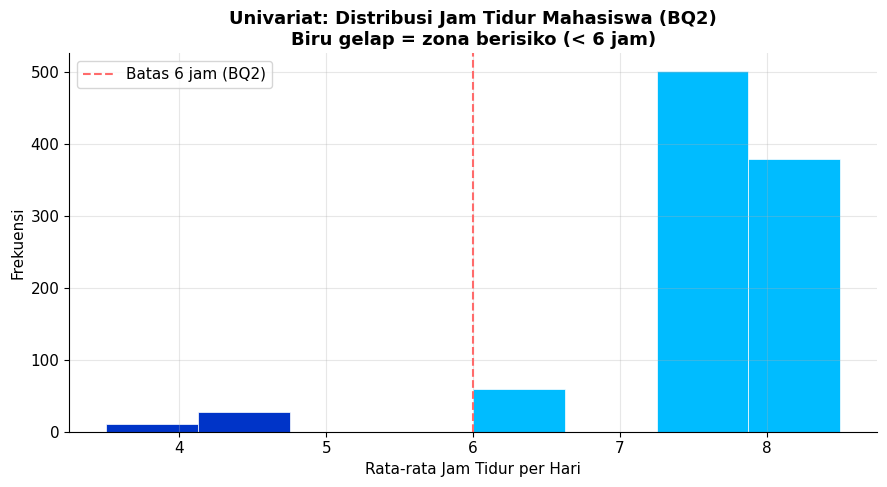

Mahasiswa tidur < 6 jam : 3.9%
Mean   : 7.70 jam
Median : 7.50 jam


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
counts, bins, patches = ax.hist(
    df_c['avg_sleep_hours_num'].dropna(), bins=8, edgecolor='white', linewidth=0.5)
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor(C_DARK if left < 6 else C_LIGHT)
ax.axvline(6, color='#FF6B6B', linestyle='--', linewidth=1.5, label='Batas 6 jam (BQ2)')
ax.set_xlabel('Rata-rata Jam Tidur per Hari')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.set_title(
    'Univariat: Distribusi Jam Tidur Mahasiswa (BQ2)\n'
    'Biru gelap = zona berisiko (< 6 jam)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uni_sleep_hist.png', dpi=150, bbox_inches='tight')
plt.show()

pct = (df_c['avg_sleep_hours_num'] < 6).mean() * 100
print(f'Mahasiswa tidur < 6 jam : {pct:.1f}%')
print(f'Mean   : {df_c["avg_sleep_hours_num"].mean():.2f} jam')
print(f'Median : {df_c["avg_sleep_hours_num"].median():.2f} jam')

**Distribusi Jam Tidur (BQ2)**

Histogram menggunakan nilai tengah dari range teks (`'4-5 hours'` = 4.5, `'7-8 hours'` = 7.5). Bin di bawah 6 jam disorot dengan `#0034c8` (gelap) sebagai zona berisiko, sedangkan bin di atas threshold menggunakan `#00bcff` (terang). Garis merah menandai threshold 6 jam sebagai titik pembanding BQ2.

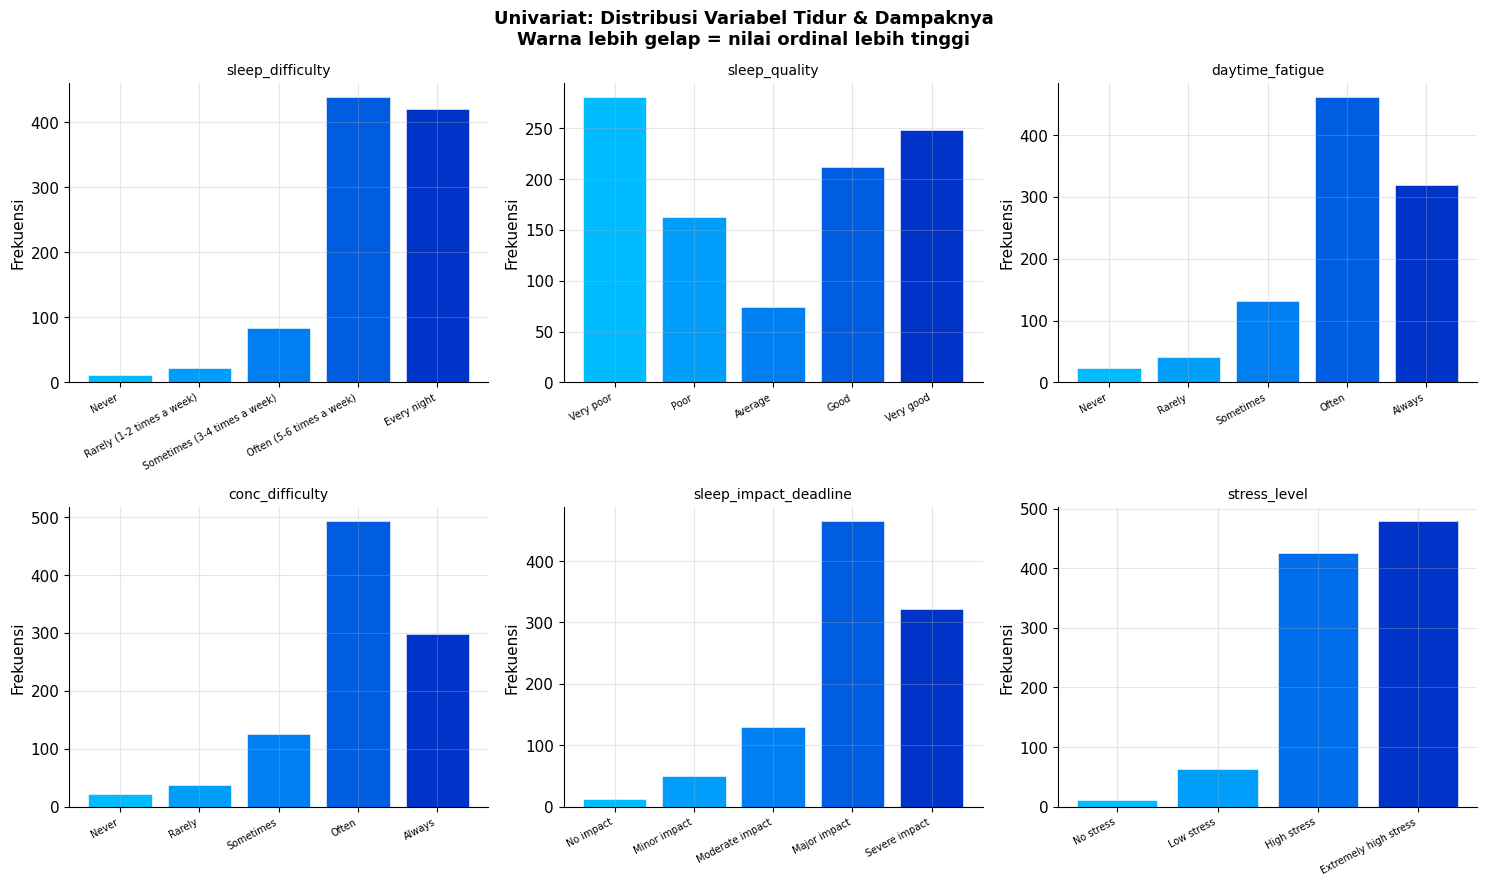

In [16]:
plot_cols = ['sleep_difficulty', 'sleep_quality', 'daytime_fatigue',
             'conc_difficulty', 'sleep_impact_deadline', 'stress_level']
plot_cols = [c for c in plot_cols if c in df_c.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    vc = df_c[col].value_counts()
    num_col = f'{col}_num'
    if num_col in df_c.columns:
        order = df_c.groupby(col)[num_col].mean().sort_values().index.tolist()
        vc = vc.reindex(order).dropna()
    n_bars = len(vc)
    bar_colors = [PALETTE[int(j*(len(PALETTE)-1)/max(n_bars-1,1))] for j in range(n_bars)]
    axes[i].bar(range(n_bars), vc.values, color=bar_colors, edgecolor='white', linewidth=0.4)
    axes[i].set_xticks(range(n_bars))
    axes[i].set_xticklabels(vc.index, rotation=28, ha='right', fontsize=7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frekuensi')

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Univariat: Distribusi Variabel Tidur & Dampaknya\nWarna lebih gelap = nilai ordinal lebih tinggi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uni_ordinal_vars.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribusi Variabel Ordinal Tidur**

Setiap bar chart diurutkan berdasarkan nilai ordinal numerik (dari terendah ke tertinggi) menggunakan rata-rata `_num` per kategori. Gradasi warna dari terang ke gelap memperkuat hierarki ordinal sesuai prinsip *darker-is-more*. Batang terpendek di kiri = kondisi paling ringan, terpanjang di kanan = kondisi paling berat.

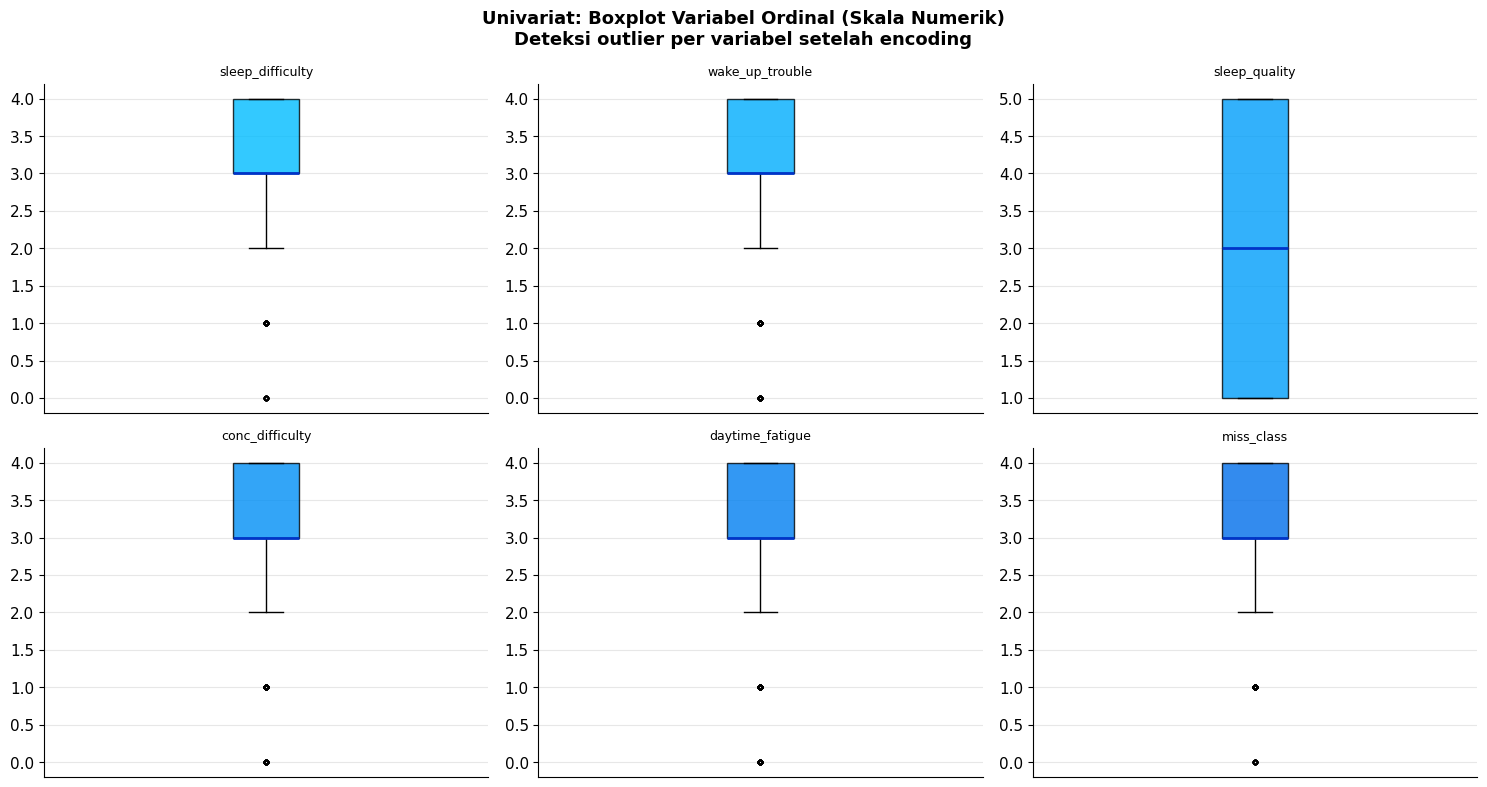

In [17]:
num_avail = [c for c in num_cols if df_c[c].notna().sum() > 10 and c != 'avg_sleep_hours_num']
n = min(len(num_avail), 6)
if n > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(num_avail[:6]):
        bp = axes[i].boxplot(df_c[col].dropna(), patch_artist=True,
                             medianprops=dict(color=C_DARK, linewidth=2),
                             flierprops=dict(marker='o', markersize=3, color=C_DARK))
        bp['boxes'][0].set_facecolor(PALETTE[i % len(PALETTE)])
        bp['boxes'][0].set_alpha(0.8)
        axes[i].set_title(col.replace('_num',''), fontsize=9)
        axes[i].set_xticks([])
    for j in range(len(num_avail[:6]), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle('Univariat: Boxplot Variabel Ordinal (Skala Numerik)\nDeteksi outlier per variabel setelah encoding',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('uni_boxplot_ordinal.png', dpi=150, bbox_inches='tight')
    plt.show()

**Boxplot Variabel Ordinal Setelah Encoding**

Setelah encoding ke skala numerik, boxplot dapat digunakan untuk melihat sebaran dan outlier. Median yang tinggi (garis tebal di tengah) menandakan mayoritas responden berada di sisi berat dari skala ordinal tersebut.

### Analisis Bivariat
Meneliti hubungan antara dua variabel.


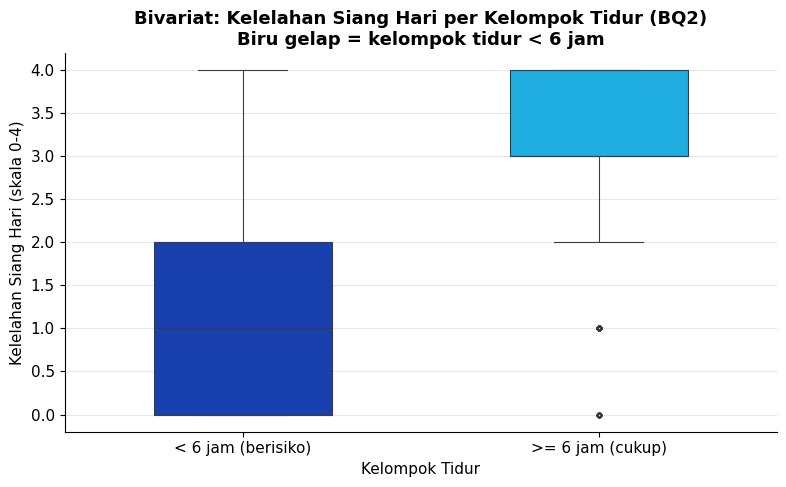

Rata-rata & Median kelelahan per kelompok tidur:
                     mean  median
sleep_group                      
< 6 jam (berisiko)  1.421     1.0
>= 6 jam (cukup)    3.099     3.0


In [18]:
grp_order = ['< 6 jam (berisiko)', '>= 6 jam (cukup)']
pal = {'< 6 jam (berisiko)': C_DARK, '>= 6 jam (cukup)': C_LIGHT}

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_c, x='sleep_group', y='daytime_fatigue_num',
    hue='sleep_group', order=grp_order, hue_order=grp_order,
    palette=pal, legend=False, ax=ax,
    linewidth=0.8, width=0.5,
    flierprops=dict(marker='o', markersize=3)
)
ax.set_xlabel('Kelompok Tidur')
ax.set_ylabel('Kelelahan Siang Hari (skala 0-4)')
ax.set_title('Bivariat: Kelelahan Siang Hari per Kelompok Tidur (BQ2)\nBiru gelap = kelompok tidur < 6 jam',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('biv_sleepgroup_vs_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rata-rata & Median kelelahan per kelompok tidur:')
print(df_c.groupby('sleep_group')['daytime_fatigue_num'].agg(['mean','median']).round(3))

**Kelelahan Siang Hari per Kelompok Tidur (BQ2)**

Boxplot membandingkan distribusi `daytime_fatigue_num` antara mahasiswa yang tidur kurang dari 6 jam vs yang cukup. Jika median dan distribusi kelompok biru gelap lebih tinggi, hipotesis BQ2 terdukung secara visual sebelum dikonfirmasi dengan uji statistik.

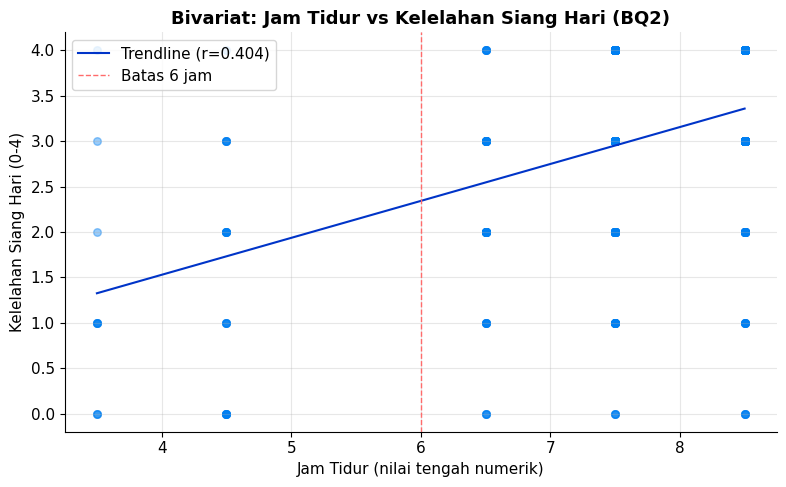

Korelasi Pearson avg_sleep_hours_num vs daytime_fatigue_num: r = 0.404
Korelasi positif.


In [19]:
valid = df_c[['avg_sleep_hours_num','daytime_fatigue_num']].dropna()
r = valid['avg_sleep_hours_num'].corr(valid['daytime_fatigue_num'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(valid['avg_sleep_hours_num'], valid['daytime_fatigue_num'],
           alpha=0.4, color=C_MAIN, s=30)
m, b = np.polyfit(valid['avg_sleep_hours_num'], valid['daytime_fatigue_num'], 1)
x_ = np.linspace(valid['avg_sleep_hours_num'].min(), valid['avg_sleep_hours_num'].max(), 100)
ax.plot(x_, m*x_+b, color=C_DARK, linewidth=1.5, label=f'Trendline (r={r:.3f})')
ax.axvline(6, color='#FF6B6B', linestyle='--', linewidth=1, label='Batas 6 jam')
ax.set_xlabel('Jam Tidur (nilai tengah numerik)')
ax.set_ylabel('Kelelahan Siang Hari (0-4)')
ax.legend()
ax.set_title('Bivariat: Jam Tidur vs Kelelahan Siang Hari (BQ2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('biv_sleep_vs_fatigue_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Korelasi Pearson avg_sleep_hours_num vs daytime_fatigue_num: r = {r:.3f}')
print('Korelasi negatif = semakin sedikit tidur, semakin tinggi kelelahan.' if r < 0 else 'Korelasi positif.')

**Jam Tidur vs Kelelahan (BQ2)**

*Scatter plot* dengan trendline menggunakan nilai numerik hasil encoding. Nilai `r` (korelasi Pearson) negatif mengkonfirmasi bahwa semakin sedikit jam tidur, semakin tinggi kelelahan siang hari.

In [20]:
g_low  = df_c[df_c['sleep_group'].str.contains('< 6')]['daytime_fatigue_num'].dropna()
g_high = df_c[df_c['sleep_group'].str.contains('>= 6')]['daytime_fatigue_num'].dropna()

stat, p = stats.mannwhitneyu(g_low, g_high, alternative='greater')

print('Uji Mann-Whitney U: Kelelahan Siang Hari')
print(f'Kelompok < 6 jam  : mean={g_low.mean():.3f}, n={len(g_low)}')
print(f'Kelompok >= 6 jam : mean={g_high.mean():.3f}, n={len(g_high)}')
print(f'U-statistic       : {stat:.2f}')
print(f'p-value           : {p:.4f}')
if p < 0.05:
    print('\nKesimpulan BQ2: Perbedaan SIGNIFIKAN (p < 0.05)')
    print('Mahasiswa dengan tidur < 6 jam memiliki kelelahan siang hari yang secara statistik lebih tinggi.')
else:
    print('\nKesimpulan BQ2: Perbedaan TIDAK signifikan (p >= 0.05)')

Uji Mann-Whitney U: Kelelahan Siang Hari
Kelompok < 6 jam  : mean=1.421, n=38
Kelompok >= 6 jam : mean=3.099, n=940
U-statistic       : 5239.00
p-value           : 1.0000

Kesimpulan BQ2: Perbedaan TIDAK signifikan (p >= 0.05)


**Uji Mann-Whitney U (BQ2)**

Uji non-parametrik digunakan karena data berasal dari encoding ordinal, bukan pengukuran numerik asli. Mann-Whitney U menguji apakah satu kelompok secara stokastik memiliki nilai lebih besar dari kelompok lain, tanpa asumsi normalitas distribusi.

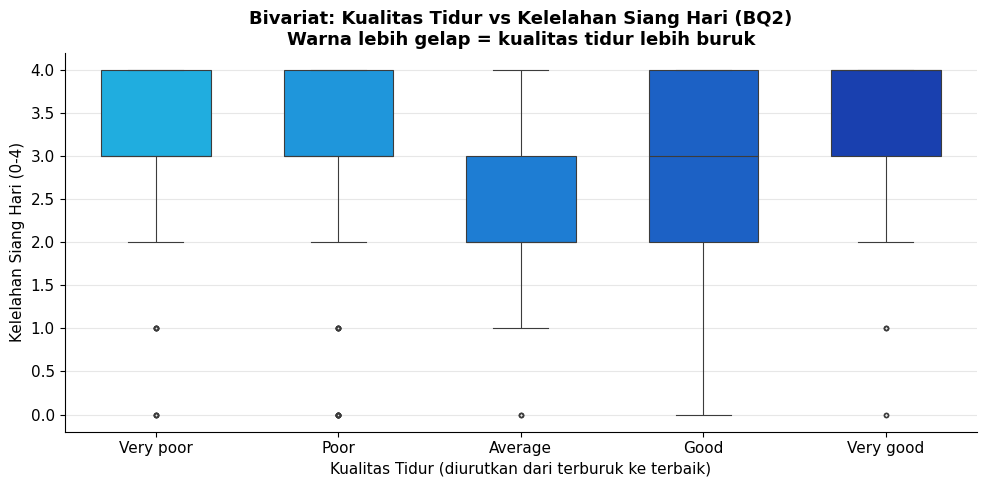

Korelasi Pearson sleep_quality_num vs daytime_fatigue_num: r = 0.092


In [21]:
order_sq = df_c.groupby('sleep_quality')['sleep_quality_num'].mean().sort_values().index.tolist()
n = len(order_sq)
pal_sq = {l: PALETTE[int(i*(len(PALETTE)-1)/max(n-1,1))] for i, l in enumerate(order_sq)}

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_c, x='sleep_quality', y='daytime_fatigue_num',
    hue='sleep_quality', order=order_sq, hue_order=order_sq,
    palette=pal_sq, legend=False, ax=ax,
    linewidth=0.8, width=0.6,
    flierprops=dict(marker='o', markersize=3)
)
ax.set_xlabel('Kualitas Tidur (diurutkan dari terburuk ke terbaik)')
ax.set_ylabel('Kelelahan Siang Hari (0-4)')
ax.set_title('Bivariat: Kualitas Tidur vs Kelelahan Siang Hari (BQ2)\nWarna lebih gelap = kualitas tidur lebih buruk',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('biv_sleepquality_vs_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()

r_sq = df_c['sleep_quality_num'].corr(df_c['daytime_fatigue_num'])
print(f'Korelasi Pearson sleep_quality_num vs daytime_fatigue_num: r = {r_sq:.3f}')

**Kualitas Tidur vs Kelelahan (BQ2)**

Urutan kategori didasarkan pada rata-rata nilai numerik per kategori, bukan alfabet. Ini memastikan kategori tersusun dari terburuk ke terbaik secara logis. Korelasi negatif yang diharapkan: kualitas tidur buruk berasosiasi dengan kelelahan lebih tinggi.

### Analisis Multivariat
Menyelidiki interaksi tiga variabel atau lebih.

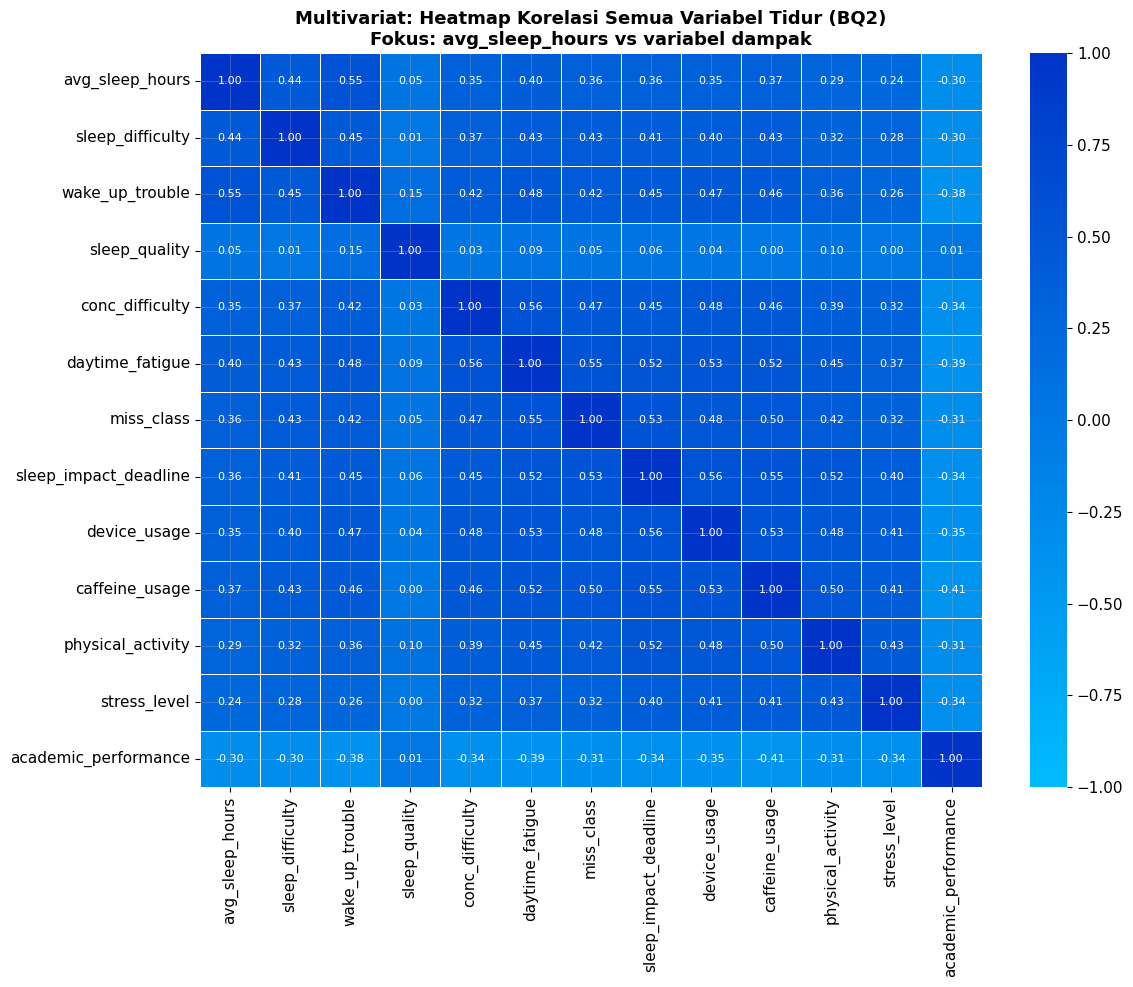

Korelasi avg_sleep_hours terhadap variabel lain (diurutkan):
academic_performance    -0.301
sleep_quality            0.053
stress_level             0.238
physical_activity        0.290
device_usage             0.347
conc_difficulty          0.353
sleep_impact_deadline    0.359
miss_class               0.360
caffeine_usage           0.371
daytime_fatigue          0.404
sleep_difficulty         0.437
wake_up_trouble          0.550
Name: avg_sleep_hours, dtype: float64


In [22]:
num_for_corr = [c for c in num_cols if df_c[c].notna().sum() > 10]
short_names = {c: c.replace('_num','') for c in num_for_corr}
corr = df_c[num_for_corr].corr().rename(index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=HAPI_CMAP,
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 8})
ax.set_title('Multivariat: Heatmap Korelasi Semua Variabel Tidur (BQ2)\nFokus: avg_sleep_hours vs variabel dampak',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multi_heatmap_sleep.png', dpi=150, bbox_inches='tight')
plt.show()

if 'avg_sleep_hours' in corr.columns:
    print('Korelasi avg_sleep_hours terhadap variabel lain (diurutkan):')
    print(corr['avg_sleep_hours'].drop('avg_sleep_hours').sort_values().round(3))

**Heatmap Korelasi Variabel Tidur (BQ2)**

Semua variabel menggunakan nilai kolom `_num`. `linewidths=0.5` dan `linecolor='white'` wajib pada heatmap untuk mencegah *simultaneous contrast* yang mendistorsi persepsi warna antar sel. Kolom `avg_sleep_hours` dengan korelasi negatif terhadap `daytime_fatigue` dan `conc_difficulty` mengkonfirmasi hipotesis BQ2.

In [23]:
vif_cols = [c for c in num_for_corr if df_c[c].notna().all()]
if len(vif_cols) >= 2:
    X_vif = df_c[vif_cols].dropna()
    vif_data = pd.DataFrame({
        'Fitur': [c.replace('_num','') for c in vif_cols],
        'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    print('VIF Check (batas aman: VIF < 1000)')
    print(vif_data.round(2))
    flag = vif_data[vif_data['VIF'] >= 1000]
    print(f'Multikolinearitas tinggi: {flag["Fitur"].tolist()}' if len(flag) > 0 else 'Semua VIF aman')

VIF Check (batas aman: VIF < 1000)
                    Fitur    VIF
0         avg_sleep_hours  59.58
1          caffeine_usage  27.46
2         wake_up_trouble  27.10
3        sleep_difficulty  26.44
4   sleep_impact_deadline  25.87
5            device_usage  25.66
6       physical_activity  25.01
7              miss_class  24.51
8         daytime_fatigue  24.24
9            stress_level  21.31
10        conc_difficulty  21.13
11          sleep_quality   4.62
12   academic_performance   4.07
Semua VIF aman


**Uji Multikolinearitas (VIF)**

Variabel tidur yang saling berkorelasi tinggi (seperti `sleep_quality` dan `daytime_fatigue`) perlu diperiksa VIF-nya sebelum keduanya digunakan bersama sebagai fitur model. Jika VIF >= 1000, pertimbangkan menggunakan hanya satu fitur yang paling representatif.

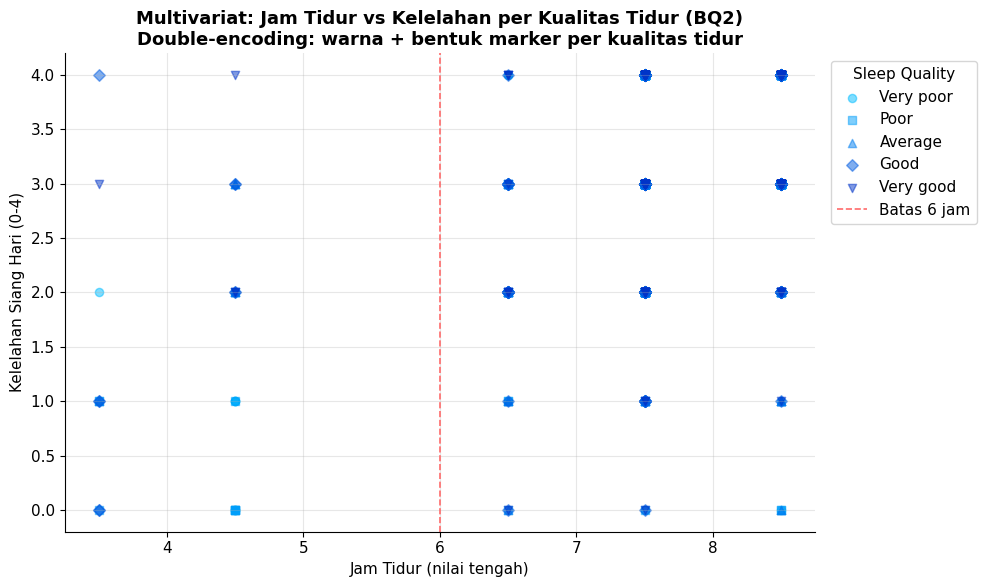

In [24]:
valid3 = df_c.dropna(subset=['avg_sleep_hours_num','daytime_fatigue_num','sleep_quality'])
quals = valid3.groupby('sleep_quality')['sleep_quality_num'].mean().sort_values().index.tolist()
n = len(quals)
cmap_3 = {q: PALETTE[int(i*(len(PALETTE)-1)/max(n-1,1))] for i, q in enumerate(quals)}
mkr_map = {q: m for q, m in zip(quals, ['o','s','^','D','v'])}

fig, ax = plt.subplots(figsize=(10, 6))
for q in quals:
    mask = valid3['sleep_quality'] == q
    ax.scatter(
        valid3.loc[mask, 'avg_sleep_hours_num'],
        valid3.loc[mask, 'daytime_fatigue_num'],
        c=cmap_3[q], marker=mkr_map.get(q, 'o'),
        alpha=0.5, s=35, label=q)
ax.axvline(6, color='#FF6B6B', linestyle='--', linewidth=1.2, label='Batas 6 jam')
ax.set_xlabel('Jam Tidur (nilai tengah)')
ax.set_ylabel('Kelelahan Siang Hari (0-4)')
ax.legend(title='Sleep Quality', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title('Multivariat: Jam Tidur vs Kelelahan per Kualitas Tidur (BQ2)\nDouble-encoding: warna + bentuk marker per kualitas tidur',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multi_scatter_3var_sleep.png', dpi=150, bbox_inches='tight')
plt.show()

**Scatter 3 Variabel: Jam Tidur, Kelelahan, Kualitas Tidur (BQ2)**

*Double-encoding* (warna + bentuk marker) digunakan untuk variabel ketiga `sleep_quality`. Urutan kategori didasarkan pada nilai numerik, bukan alfabet. Pola yang diharapkan: cluster biru gelap (kualitas buruk) berkumpul di sudut kiri-atas (tidur sedikit, kelelahan tinggi), sedangkan cluster biru terang (kualitas baik) berkumpul di kanan-bawah.

### Rekomendasi Pemodelan

In [25]:
print('Ringkasan EDA: Sleep Insomnia')
print(f'Total responden: {len(df_c):,}')
print(f'Mean jam tidur : {df_c["avg_sleep_hours_num"].mean():.2f} jam')
print(f'Mahasiswa tidur < 6 jam: {(df_c["avg_sleep_hours_num"] < 6).mean()*100:.1f}%')
print('\nDistribusi sleep_impact_deadline:')
print(df_c['sleep_impact_deadline'].value_counts())

Ringkasan EDA: Sleep Insomnia
Total responden: 978
Mean jam tidur : 7.70 jam
Mahasiswa tidur < 6 jam: 3.9%

Distribusi sleep_impact_deadline:
sleep_impact_deadline
Major impact       465
Severe impact      322
Moderate impact    129
Minor impact        50
No impact           12
Name: count, dtype: int64


**Rekomendasi**

- **BQ2:** Jika uji Mann-Whitney U signifikan (p < 0.05), `avg_sleep_hours_num` adalah fitur prediktif kuat untuk model burnout. Threshold 6 jam dapat dijadikan fitur biner (`is_sleep_deprived`) untuk memperkuat sinyal dalam **Fatigue Score Fusion Model**.
- `sleep_quality_num`, `daytime_fatigue_num`, dan `conc_difficulty_num` menunjukkan korelasi tinggi satu sama lain. Pilih fitur paling representatif atau terapkan PCA untuk menghindari multikolinearitas.
- Semua kolom `_num` siap digunakan sebagai fitur model tanpa preprocessing tambahan.